In [4]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier,export_graphviz
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt


In [7]:
data_import=pd.read_csv("final_test.csv")
data_import

,weight,age,height,size
0,62,28.0,172.72,XL
1,59,36.0,167.64,L
2,61,34.0,165.10,M
3,65,27.0,175.26,L
4,62,45.0,172.72,M
...,...,...,...,...
119729,63,42.0,175.26,M
119730,45,29.0,154.94,S
119731,61,31.0,172.72,M
119732,74,31.0,167.64,XL


In [8]:
data_import["size"].value_counts()


size
M       29712
S       21924
XXXL    21359
XL      19119
L       17587
XXS      9964
XXL        69
Name: count, dtype: int64

In [9]:
data_step_one=data_import.copy()
data_step_one=data_step_one.dropna(axis=0)
dropped_rows=len(data_import)-len(data_step_one)
print("Rows Dropped: ",dropped_rows)

Rows Dropped:  581


In [10]:
data_step_one=data_step_one[data_step_one["size"]!="XXL"]
data_step_one

,weight,age,height,size
0,62,28.0,172.72,XL
1,59,36.0,167.64,L
2,61,34.0,165.10,M
3,65,27.0,175.26,L
4,62,45.0,172.72,M
...,...,...,...,...
119729,63,42.0,175.26,M
119730,45,29.0,154.94,S
119731,61,31.0,172.72,M
119732,74,31.0,167.64,XL


In [11]:
X=data_step_one[["weight","age","height"]]
y=data_step_one["size"]

In [12]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33)

In [18]:
def decision_tree_run(depth):
    tree_clf=DecisionTreeClassifier(max_depth=depth)
    tree_clf.fit(X_train,y_train)
    return tree_clf.score(X_test,y_test)
decision_tree_run(None)

0.5034607359153137

In [14]:
accuracy=[]
tree_depth=list(range(2,100,3))


In [15]:
for i in tree_depth:
    accuracy.append(decision_tree_run(i))
accuracy

[0.4541961422973179,
 0.5038169881418901,
 0.5169728739376049,
 0.514606341289633,
 0.5095424703547254,
 0.504911191409232,
 0.5031553768639625,
 0.5032317166268003,
 0.503384396152476,
 0.5033080563896382,
 0.5034098427400886,
 0.5032826098020255,
 0.5035116290905389,
 0.5034352893277012,
 0.5032826098020255,
 0.5034607359153137,
 0.5032317166268003,
 0.5034098427400886,
 0.5032826098020255,
 0.503384396152476,
 0.5032062700391877,
 0.5033589495648634,
 0.5033335029772508,
 0.5032826098020255,
 0.5033335029772508,
 0.5032317166268003,
 0.5033080563896382,
 0.5034607359153137,
 0.5032317166268003,
 0.5034352893277012,
 0.5033589495648634,
 0.5032317166268003,
 0.5032826098020255]

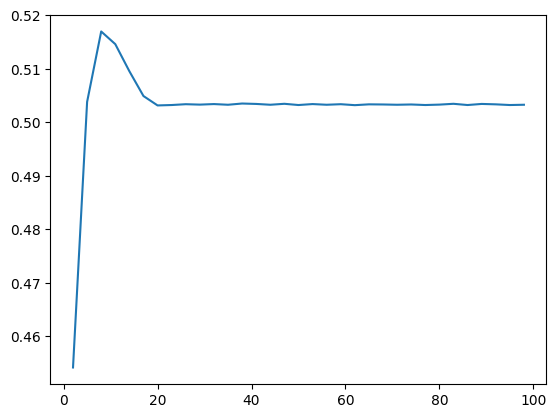

In [16]:
plt.plot(tree_depth,accuracy)

In [20]:
##results=pd.DataFrame(data={"Predictions":tree_clf_predict(X_test).tolist(),"Actuals":y_test.to_list()})
##results["Matching"]=results.apply(lambda x:"Correct" if x["Predictions"]==x["Actuals"] else "Wrong",axis=1)